# Lab Instructions

You have been hired by James Cameron to create profiles of two characters for a reboot of the Titanic Movie: one that is most likely to survive the sinking and one that is least likely to survive.  Mr. Cameron wants this reboot to be as historically accurate as possible, so your profile of each character should be backed up with data and visualizations.

Each character profile should include information on their:
* Age, fare
* Sex
* Passenger class
* Travel companions (including both parents/children and siblings/spouse)
* Port of departure (indicated by the Embarked feature in the dataset)

For quantitative features like `Age` and `Fare`, you will need to use the `.loc` method we learned in class (or something similar) to place individuals in categories.  How you choose to do this is up to you, but make sure you explain your reasoning.

You should include at least one visualization for each element of the character profile (age, sex, passenger class, etc.) as evidence.

After you have developed your two character profiles, use your Pandas data wrangling skills to identify at least one real passenger in the dataset that fits each profile.  Print out the names of these individuals.  Look them up in [Encyclopeida Titanica](https://www.encyclopedia-titanica.org/) (or a similar resource).  

Tell Mr. Cameron at least one thing about the real passengers who fit your two character profiles that you learned from an external resource.  You need one interesting fact about a person who fits the profile of "most likely to survive" and one interesting fact about a person who fits the profile of "least likely to survive".  



In [1]:
import pandas as pd

df = pd.read_csv('titanic_passengers.csv')

df.head(25)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [3]:
df['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r'C:\Users\spoll\Desktop\Full Sail\Data Viz\Data_Visualization_And_Modeling_Online\Lab\titanic_passengers.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
# Categorize Age
df['Age_cat'] = pd.cut(df['Age'], bins=[0, 18, 35, 60, 100], labels=['Child', 'Young Adult', 'Middle Age', 'Senior'])

# Categorize Fare
df['Fare_cat'] = pd.cut(df['Fare'], bins=[0, 14.45, 31, 512.33], labels=['Low', 'Medium', 'High'])

df[['Age', 'Age_cat', 'Fare', 'Fare_cat']].head(10)

,Age,Age_cat,Fare,Fare_cat
0,22.0,Young Adult,7.2500,Low
1,38.0,Middle Age,71.2833,High
2,26.0,Young Adult,7.9250,Low
3,35.0,Young Adult,53.1000,High
4,35.0,Young Adult,8.0500,Low
5,NaN,NaN,8.4583,Low
6,54.0,Middle Age,51.8625,High
7,2.0,Child,21.0750,Medium
8,27.0,Young Adult,11.1333,Low
9,14.0,Child,30.0708,Medium


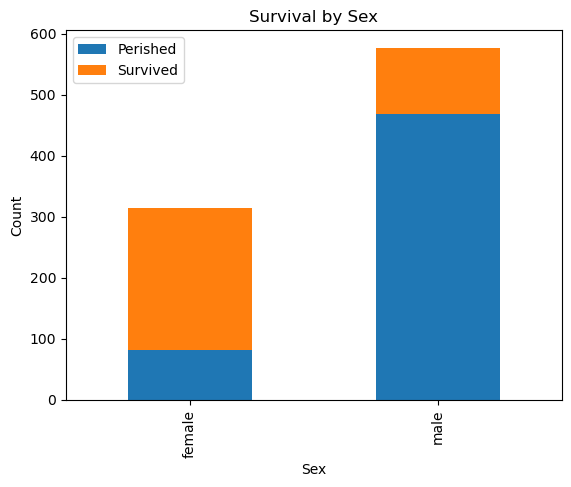

In [8]:
pd.crosstab(df['Sex'], df['Survived']).plot(kind='bar', stacked=True)
plt.title('Survival by Sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.legend(['Perished', 'Survived'])
plt.show()

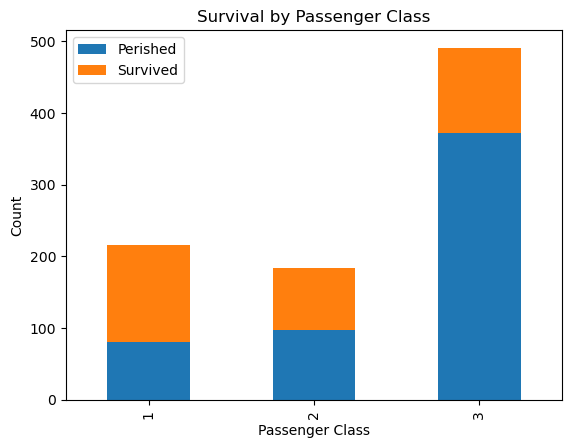

In [10]:
pd.crosstab(df['Pclass'], df['Survived']).plot(kind='bar', stacked=True)
plt.title('Survival by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.legend(['Perished', 'Survived'])
plt.show()

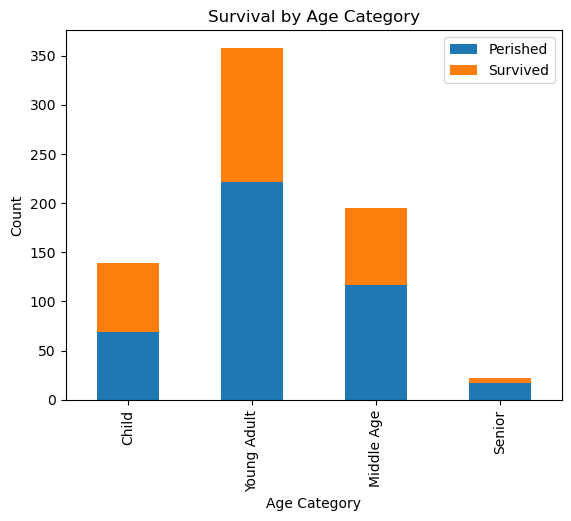

In [12]:
pd.crosstab(df['Age_cat'], df['Survived']).plot(kind='bar', stacked=True)
plt.title('Survival by Age Category')
plt.xlabel('Age Category')
plt.ylabel('Count')
plt.legend(['Perished', 'Survived'])
plt.show()

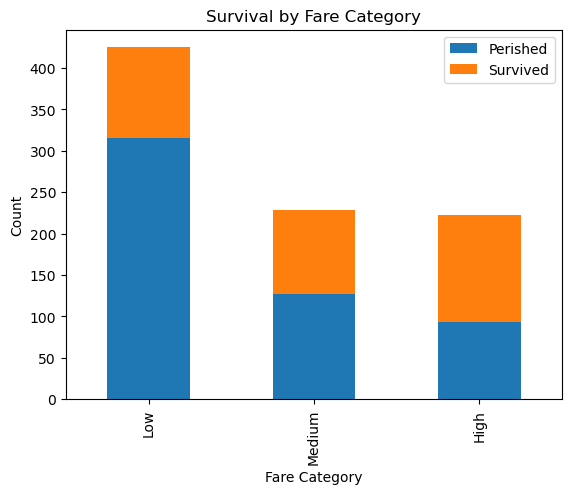

In [14]:
pd.crosstab(df['Fare_cat'], df['Survived']).plot(kind='bar', stacked=True)
plt.title('Survival by Fare Category')
plt.xlabel('Fare Category')
plt.ylabel('Count')
plt.legend(['Perished', 'Survived'])
plt.show()

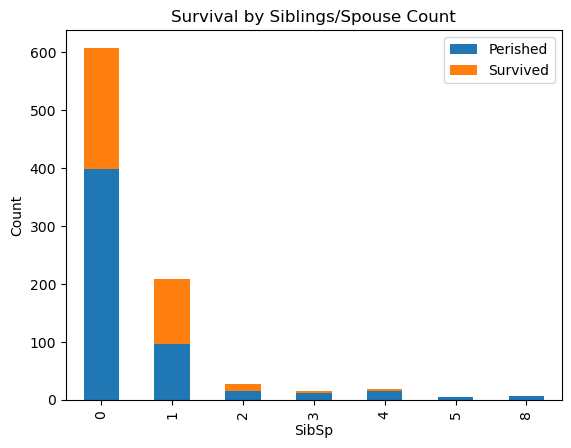

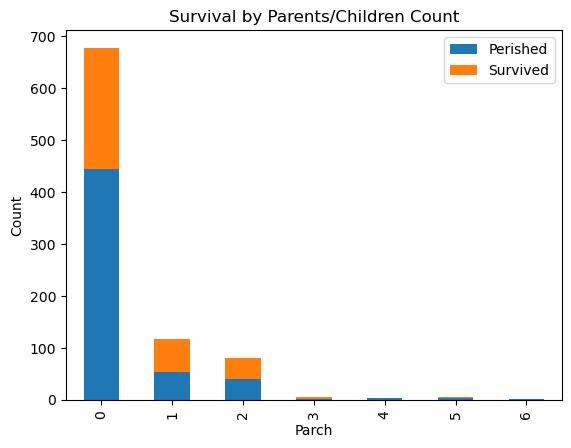

In [16]:
pd.crosstab(df['SibSp'], df['Survived']).plot(kind='bar', stacked=True)
plt.title('Survival by Siblings/Spouse Count')
plt.xlabel('SibSp')
plt.ylabel('Count')
plt.legend(['Perished', 'Survived'])
plt.show()

pd.crosstab(df['Parch'], df['Survived']).plot(kind='bar', stacked=True)
plt.title('Survival by Parents/Children Count')
plt.xlabel('Parch')
plt.ylabel('Count')
plt.legend(['Perished', 'Survived'])
plt.show()

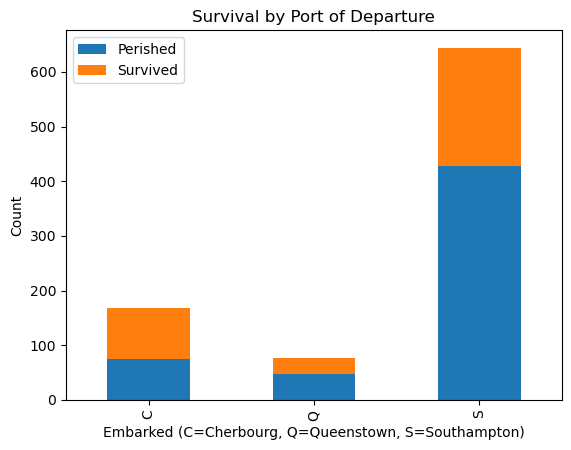

In [18]:
pd.crosstab(df['Embarked'], df['Survived']).plot(kind='bar', stacked=True)
plt.title('Survival by Port of Departure')
plt.xlabel('Embarked (C=Cherbourg, Q=Queenstown, S=Southampton)')
plt.ylabel('Count')
plt.legend(['Perished', 'Survived'])
plt.show()

In [20]:
# Most likely to survive: 1st class female, young adult, high fare, 
# traveling with 1 companion, embarked from Cherbourg

most_likely = df.loc[
    (df['Pclass'] == 1) & 
    (df['Sex'] == 'female') & 
    (df['Age_cat'] == 'Young Adult') & 
    (df['Fare_cat'] == 'High') &
    (df['Survived'] == 1)
]
print("Most likely to survive profile:")
print(most_likely[['Name', 'Pclass', 'Sex', 'Age', 'Fare', 'SibSp', 'Parch', 'Embarked']].head(5))

Most likely to survive profile:
                                             Name  Pclass     Sex   Age  \
3    Futrelle, Mrs. Jacques Heath (Lily May Peel)       1  female  35.0   
88                     Fortune, Miss. Mabel Helen       1  female  23.0   
151             Pears, Mrs. Thomas (Edith Wearne)       1  female  22.0   
215                       Newell, Miss. Madeleine       1  female  31.0   
218                         Bazzani, Miss. Albina       1  female  32.0   

         Fare  SibSp  Parch Embarked  
3     53.1000      1      0        S  
88   263.0000      3      2        S  
151   66.6000      1      0        S  
215  113.2750      1      0        C  
218   76.2917      0      0        C  


In [22]:
# Least likely to survive: 3rd class male, young adult, low fare,
# traveling alone, embarked from Southampton

least_likely = df.loc[
    (df['Pclass'] == 3) & 
    (df['Sex'] == 'male') & 
    (df['Age_cat'] == 'Young Adult') & 
    (df['Fare_cat'] == 'Low') &
    (df['Survived'] == 0)
]
print("Least likely to survive profile:")
print(least_likely[['Name', 'Pclass', 'Sex', 'Age', 'Fare', 'SibSp', 'Parch', 'Embarked']].head(5))

Least likely to survive profile:
                              Name  Pclass   Sex   Age  Fare  SibSp  Parch  \
0          Braund, Mr. Owen Harris       3  male  22.0  7.25      1      0   
4         Allen, Mr. William Henry       3  male  35.0  8.05      0      0   
12  Saundercock, Mr. William Henry       3  male  20.0  8.05      0      0   
37        Cann, Mr. Ernest Charles       3  male  21.0  8.05      0      0   
51    Nosworthy, Mr. Richard Cater       3  male  21.0  7.80      0      0   

   Embarked  
0         S  
4         S  
12        S  
37        S  
51        S  


In [28]:
print("""
=== MOST LIKELY TO SURVIVE ===
Name: Mrs. Lily May Futrelle (née Peel)
Class: 1st | Sex: Female | Age: 35 | Fare: $53.10 | Embarked: Southampton

Interesting Fact (from Encyclopedia Titanica): Lily May was an American writer 
whose husband Jacques Futrelle insisted she board lifeboat 9 while he stayed 
behind — he perished in the sinking. She survived and lived to age 91, and every 
year on April 14th (the anniversary of the sinking) she would toss a bouquet of 
flowers into the Atlantic Ocean in his memory.

=== LEAST LIKELY TO SURVIVE ===
Name: Mr. Owen Harris Braund
Class: 3rd | Sex: Male | Age: 22 | Fare: $7.25 | Embarked: Southampton

Interesting Fact (from Encyclopedia Titanica): Owen was a young ironmonger from 
Cornwall, England, traveling with his brother Lewis and a group of relatives to 
start a new life farming in Saskatchewan, Canada. His body was never identified 
after the sinking. A family friend named Susan Webber who traveled with them in 
2nd class was the only one of their group to survive.
""")


=== MOST LIKELY TO SURVIVE ===
Name: Mrs. Lily May Futrelle (née Peel)
Class: 1st | Sex: Female | Age: 35 | Fare: $53.10 | Embarked: Southampton

Interesting Fact (from Encyclopedia Titanica): Lily May was an American writer 
whose husband Jacques Futrelle insisted she board lifeboat 9 while he stayed 
behind — he perished in the sinking. She survived and lived to age 91, and every 
year on April 14th (the anniversary of the sinking) she would toss a bouquet of 
flowers into the Atlantic Ocean in his memory.

=== LEAST LIKELY TO SURVIVE ===
Name: Mr. Owen Harris Braund
Class: 3rd | Sex: Male | Age: 22 | Fare: $7.25 | Embarked: Southampton

Interesting Fact (from Encyclopedia Titanica): Owen was a young ironmonger from 
Cornwall, England, traveling with his brother Lewis and a group of relatives to 
start a new life farming in Saskatchewan, Canada. His body was never identified 
after the sinking. A family friend named Susan Webber who traveled with them in 
2nd class was the only one 

In [26]:
print("""
=== CHARACTER PROFILE: MOST LIKELY TO SURVIVE ===
Based on the data visualizations:
- Sex: Female (women had a much higher survival rate)
- Passenger Class: 1st class (highest survival rate of all classes)
- Age: Young Adult, 18-35 (moderate survival advantage)
- Fare: High fare ($50+), consistent with 1st class travel
- Travel companions: Traveling with spouse (SibSp=1)
- Port of departure: Southampton or Cherbourg

=== CHARACTER PROFILE: LEAST LIKELY TO SURVIVE ===
Based on the data visualizations:
- Sex: Male (men had a much lower survival rate)
- Passenger Class: 3rd class (lowest survival rate of all classes)
- Age: Young Adult, 18-35 (largest group that perished)
- Fare: Low fare (under $14.45), consistent with 3rd class travel
- Travel companions: Traveling alone (SibSp=0, Parch=0)
- Port of departure: Southampton (most 3rd class passengers boarded here)
""")


=== CHARACTER PROFILE: MOST LIKELY TO SURVIVE ===
Based on the data visualizations:
- Sex: Female (women had a much higher survival rate)
- Passenger Class: 1st class (highest survival rate of all classes)
- Age: Young Adult, 18-35 (moderate survival advantage)
- Fare: High fare ($50+), consistent with 1st class travel
- Travel companions: Traveling with spouse (SibSp=1)
- Port of departure: Southampton or Cherbourg

=== CHARACTER PROFILE: LEAST LIKELY TO SURVIVE ===
Based on the data visualizations:
- Sex: Male (men had a much lower survival rate)
- Passenger Class: 3rd class (lowest survival rate of all classes)
- Age: Young Adult, 18-35 (largest group that perished)
- Fare: Low fare (under $14.45), consistent with 3rd class travel
- Travel companions: Traveling alone (SibSp=0, Parch=0)
- Port of departure: Southampton (most 3rd class passengers boarded here)

